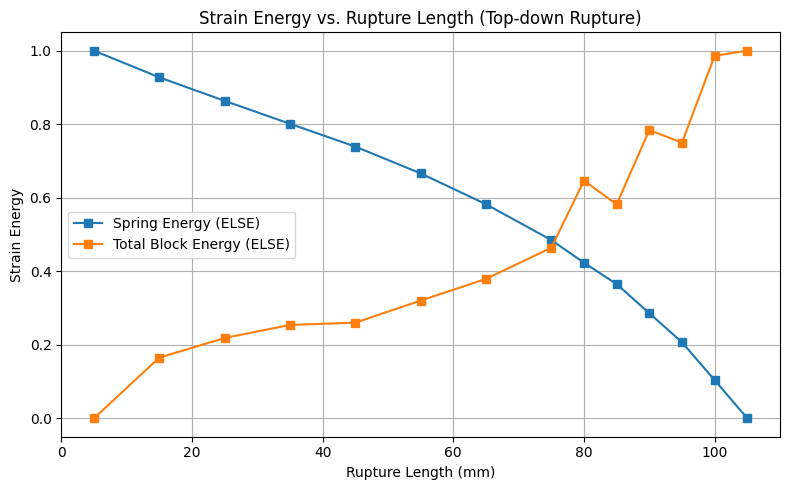

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

RUPTURE_POSITIONS = [105, 100, 95, 90, 85, 80, 75, 65, 55, 45, 35, 25, 15, 5]

def norm(array: np.ndarray) -> np.ndarray:
    """Normalize the array to the range [0, 1]."""
    return (array - np.min(array)) / (np.max(array) - np.min(array))

spring_energies = []
center_block_energies = []
left_block_energies = []
right_block_energies = []
steel_plate_block_energies = []

for RUPTURE_POSITION in RUPTURE_POSITIONS:
    filename = f'./npz/strain-energy-{RUPTURE_POSITION}.npz'
    if not os.path.exists(filename):
        print(f"[WARNING] File {filename} not found. Skipping.")
        continue

    data = np.load(filename)
    spring_energies.append(data.get('ELSE-Spring', np.nan))
    center_block_energies.append(data.get('ELSE-Center-Block', np.nan))
    left_block_energies.append(data.get('ELSE-Left-Block', np.nan))
    right_block_energies.append(data.get('ELSE-Right-Block', np.nan))
    steel_plate_block_energies.append(data.get('ELSE-Steel-Plate', np.nan))

spring_energies = np.array(spring_energies)
center_block_energies = np.array(center_block_energies)
left_block_energies = np.array(left_block_energies)
right_block_energies = np.array(right_block_energies)
steel_plate_block_energies = np.array(steel_plate_block_energies)

TOTAL_ENERGY = spring_energies + center_block_energies + left_block_energies + right_block_energies + steel_plate_block_energies

plt.figure(figsize=(8, 5))
plt.plot(RUPTURE_POSITIONS, norm(spring_energies), 's-', label='Spring Energy (ELSE)')
# plt.plot(RUPTURE_POSITIONS, center_block_energies, 's-', label='Center Block Energy (ELSE)')
# plt.plot(RUPTURE_POSITIONS, left_block_energies, 's-', label='Left Block Energy (ELSE)')
# plt.plot(RUPTURE_POSITIONS, right_block_energies, 's-', label='Right Block Energy (ELSE)')
# plt.plot(RUPTURE_POSITIONS, steel_plate_block_energies, 's-', label='Steel Plate Energy (ELSE)')

plt.plot(RUPTURE_POSITIONS, norm(center_block_energies+left_block_energies+right_block_energies), 's-', label='Total Block Energy (ELSE)')
# plt.plot(RUPTURE_POSITIONS, left_block_energies+right_block_energies, 's-', label='Total Side Block Energy (ELSE)')
# plt.plot(RUPTURE_POSITIONS, TOTAL_ENERGY, 'o-', label='Total Energy (ELSE)', color='black')

plt.xlabel('Rupture Length (mm)')
plt.ylabel('Strain Energy')
plt.title('Strain Energy vs. Rupture Length (Top-down Rupture)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Strain-energies.pdf', dpi=300)
plt.show()